# <font color="#418FDE" size="6.5" uppercase>**Risks and Fairness**</font>

>Last update: 20260424.
    
By the end of this Lecture, you will be able to:
- Identify safety, fairness, and transparency risks associated with AI models in civil engineering applications. 
- Conduct a simple cohort analysis to compare model performance across different groups or conditions. 
- Interpret cohort analysis results and propose mitigations for identified performance gaps. 


## **1. AI Risk Types**

### **1.1. Critical Failure Risks**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_13/Lecture_A/image_01_01.jpg?v=1777047173" width="250">



>* High-stakes AI errors can endanger infrastructure safety.
>* Rare conditions may cause unsafe missed defects.

>* Context and data shifts create hidden risks.
>* Overtrust in AI can reduce human checks.

>* Error costs matter more than accuracy.
>* Use safeguards; AI supports, not replaces, judgment.



TensorFlow: 2.21.0
Device: CPU
Test accuracy: 0.906
Wrong predictions: 187
Confident wrong shown: 6
High confidence can still be wrong.
In bridge screening, a missed defect
could delay inspection and raise risk.


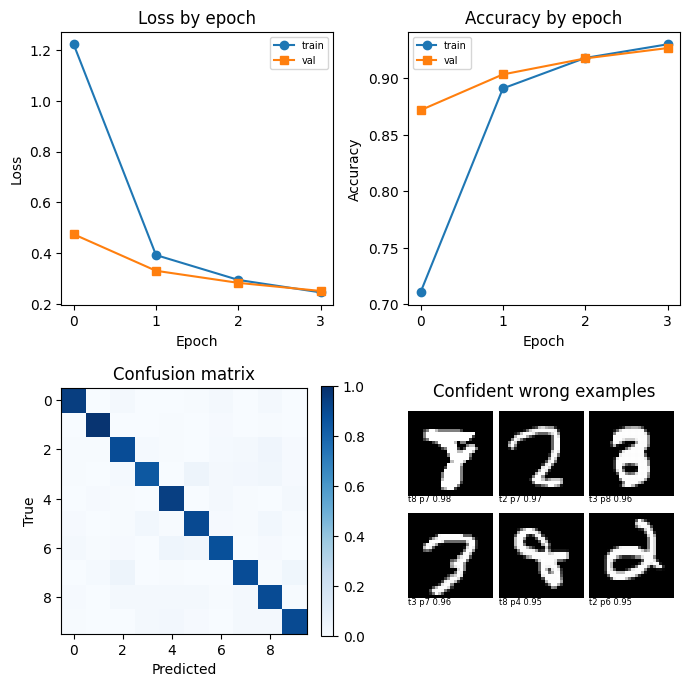

In [11]:
#@title Python Code - Critical Failure Risks

# Small classifier shows critical failure risks.
# MNIST stands in for inspection images.
# Confident mistakes can still be dangerous.

import os, warnings, random
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')
import tensorflow as tf

from sklearn.metrics import confusion_matrix

tf.get_logger().setLevel('ERROR')
np.random.seed(7)
random.seed(7)

tf.random.set_seed(7)

# Report framework and chosen device.
gpu_ok = len(tf.config.list_physical_devices('GPU')) > 0
print('TensorFlow:', tf.__version__)

print('Device:', 'GPU' if gpu_ok else 'CPU')

# Load a small image dataset.
(train_x, train_y), (test_x, test_y) = tf.keras.datasets.mnist.load_data()
train_x = train_x[:12000].astype('float32') / 255.0

test_x = test_x[:2000].astype('float32') / 255.0
train_y = train_y[:12000]
test_y = test_y[:2000]

# Add channel dimension safely.
if train_x.ndim == 3 and test_x.ndim == 3:
    train_x = np.expand_dims(train_x, -1)

    test_x = np.expand_dims(test_x, -1)

# Check shapes before training.
assert train_x.shape[0] == len(train_y)
assert test_x.shape[0] == len(test_y)

assert train_x.shape[1:] == (28, 28, 1)

# Build a very small classifier.
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),

    tf.keras.layers.Conv2D(8, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')])

# Compile with simple settings.
model.compile(
    optimizer='adam',

    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

# Train quietly for a few epochs.
history = model.fit(
    train_x, train_y,

    validation_split=0.2,
    epochs=4,
    batch_size=128,

    verbose=0)

# Evaluate quietly on test data.
test_loss, test_acc = model.evaluate(
    test_x, test_y,

    verbose=0)
print('Test accuracy:', round(float(test_acc), 3))

# Predict class probabilities.
probs = model.predict(test_x, verbose=0)
preds = np.argmax(probs, axis=1)

conf = np.max(probs, axis=1)

# Find incorrect and confident failures.
wrong_mask = preds != test_y
wrong_idx = np.where(wrong_mask)[0]

conf_wrong = wrong_idx[np.argsort(conf[wrong_idx])[::-1]]
show_idx = conf_wrong[:6]
print('Wrong predictions:', int(wrong_mask.sum()))

print('Confident wrong shown:', int(len(show_idx)))

# Build a confusion matrix.
cm = confusion_matrix(test_y, preds)
cm = cm.astype('float32')

row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = cm / np.maximum(row_sums, 1)

# Create one compact teaching figure.
fig = plt.figure(figsize=(7, 7))
ax1 = plt.subplot(2, 2, 1)

ax1.plot(history.history['loss'], marker='o', label='train')
ax1.plot(history.history['val_loss'], marker='s', label='val')
ax1.set_title('Loss by epoch')

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend(fontsize=7)

ax2 = plt.subplot(2, 2, 2)
ax2.plot(history.history['accuracy'], marker='o', label='train')
ax2.plot(history.history['val_accuracy'], marker='s', label='val')

ax2.set_title('Accuracy by epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')

ax2.legend(fontsize=7)

ax3 = plt.subplot(2, 2, 3)
im = ax3.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
ax3.set_title('Confusion matrix')

ax3.set_xlabel('Predicted')
ax3.set_ylabel('True')
plt.colorbar(im, ax=ax3, fraction=0.046)

# Show a small gallery inside one panel.
ax4 = plt.subplot(2, 2, 4)
ax4.set_title('Confident wrong examples')

ax4.axis('off')

# Fill gallery with six mistakes.
for i in range(len(show_idx)):
    idx = int(show_idx[i])

    small = test_x[idx].reshape(28, 28)
    r = i // 3
    c = i % 3

    x0 = c * 30
    y0 = r * 34
    ax4.imshow(

        small,
        cmap='gray',
        extent=(x0, x0 + 28, 68 - y0 - 28, 68 - y0),

        vmin=0,
        vmax=1)
    label = 't' + str(int(test_y[idx]))

    label = label + ' p' + str(int(preds[idx]))
    label = label + ' ' + str(round(float(conf[idx]), 2))
    ax4.text(x0, 68 - y0 - 30, label, fontsize=6)

ax4.set_xlim(0, 90)
ax4.set_ylim(0, 70)

# Explain why failures matter.
msg1 = 'High confidence can still be wrong.'
msg2 = 'In bridge screening, a missed defect'

msg3 = 'could delay inspection and raise risk.'
print(msg1)
print(msg2)

print(msg3)

plt.tight_layout()
plt.show()

### **1.2. Equity and Bias**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_13/Lecture_A/image_01_02.jpg?v=1777047215" width="250">



>* Fairness means reliable performance across all contexts.
>* Bias can worsen inequality in infrastructure decisions.

>* Bias arises across data and design stages.
>* Proxy variables can hide unequal treatment.

>* Fairness means equitable outcomes, not average accuracy.
>* Use representative data and ongoing community review.



TensorFlow version: 2.21.0
GPU available: False
       Cohort  Accuracy  Precision  Recall    F1
   Dim images     0.814      0.854   0.810 0.801
Bright images     0.905      0.905   0.905 0.904
Largest gap by metric:
Accuracy     0.091
Precision    0.051
Recall       0.095
F1           0.103


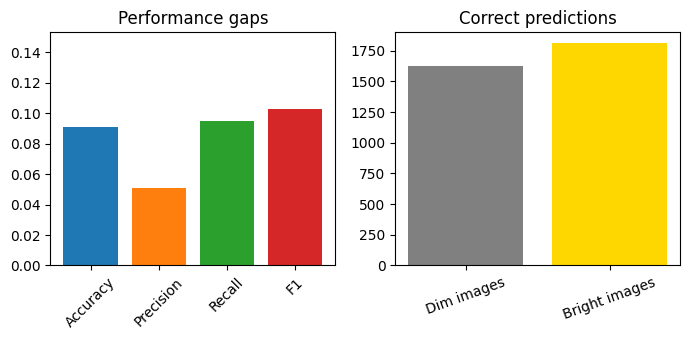

In [12]:
#@title Python Code - Equity and Bias

# Fairness example with inspection style images.
# MNIST stands in for field imagery.
# Cohorts reveal possible performance gaps.

# Import quiet libraries for Colab use.
import os, warnings, random
import numpy as np, pandas as pd

import matplotlib.pyplot as plt
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Silence TensorFlow warning messages.
warnings.filterwarnings('ignore')
import tensorflow as tf

from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import confusion_matrix

tf.get_logger().setLevel('ERROR')
np.random.seed(7)
tf.random.set_seed(7)

random.seed(7)

# Report framework version briefly.
print('TensorFlow version:', tf.__version__)
print('GPU available:', bool(tf.config.list_physical_devices('GPU')))

# Load a small MNIST subset.
(train_x, train_y), (test_x, test_y) = tf.keras.datasets.mnist.load_data()
train_x = train_x[:12000].astype('float32') / 255.0

test_x = test_x[:2000].astype('float32') / 255.0
train_y = train_y[:12000]

test_y = test_y[:2000]
if train_x.shape[0] < 1000 or test_x.shape[0] < 500:
    raise ValueError('Dataset subset is unexpectedly small.')

# Create dim and bright cohorts.
dim_x = np.clip(test_x * 0.45, 0.0, 1.0)
bright_x = np.clip(test_x * 1.35, 0.0, 1.0)

cohort_names = ['Dim images', 'Bright images']
cohort_data = [dim_x, bright_x]

# Add channel dimension for TensorFlow.
train_x = np.expand_dims(train_x, -1)
dim_x = np.expand_dims(dim_x, -1)

bright_x = np.expand_dims(bright_x, -1)

# Build a lightweight image classifier.
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),

    tf.keras.layers.Conv2D(8, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')])

# Compile the small teaching model.
model.compile(
    optimizer='adam',

    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

# Train quietly for a few epochs.
model.fit(
    train_x, train_y,

    epochs=3,
    batch_size=128,
    validation_split=0.1,

    verbose=0)

# Evaluate each cohort separately.
rows = []
matrices = []

for name, data_x in zip(cohort_names, cohort_data):
    probs = model.predict(data_x, verbose=0)
    pred_y = np.argmax(probs, axis=1)

    scores = precision_recall_fscore_support(
        test_y, pred_y, average='macro', zero_division=0)

    acc = np.mean(pred_y == test_y)
    rows.append([
        name, round(acc, 3), round(scores[0], 3),

        round(scores[1], 3), round(scores[2], 3)])
    matrices.append(confusion_matrix(test_y, pred_y))

# Build a compact metric table.
results = pd.DataFrame(
    rows,

    columns=['Cohort', 'Accuracy', 'Precision', 'Recall', 'F1'])
print(results.to_string(index=False))

# Summarize the largest metric gap.
gaps = results[['Accuracy', 'Precision', 'Recall', 'F1']].max()
gaps = gaps - results[['Accuracy', 'Precision', 'Recall', 'F1']].min()

print('Largest gap by metric:')
print(gaps.round(3).to_string())

# Plot metric gaps and confusion summaries.
fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1']

axes[0].bar(metric_names, gaps.values, color=['C0', 'C1', 'C2', 'C3'])
axes[0].set_title('Performance gaps')
axes[0].set_ylim(0, max(0.05, float(gaps.max()) + 0.05))

axes[0].tick_params(axis='x', rotation=45)

# Compare correct predictions by cohort.
correct_counts = []
for matrix in matrices:

    correct_counts.append(int(np.trace(matrix)))
axes[1].bar(cohort_names, correct_counts, color=['gray', 'gold'])
axes[1].set_title('Correct predictions')

axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

### **1.3. Model Explainability**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_13/Lecture_A/image_01_03.jpg?v=1777047259" width="250">



>* Explainability shows how AI reaches decisions.
>* It prevents blind trust in predictions.

>* Hidden model logic can mask errors.
>* Explainability reveals bias and weak evidence.

>* Explainability supports accountability across many stakeholders.
>* Clear reasons enable scrutiny and cautious trust.



TensorFlow version: 2.21.0
Rows and columns: (1030, 9)
Test MAE in MPa: 9.19
True strength: 12.47 MPa
Predicted strength: 24.65 MPa
Largest influence: Fly Ash (component 3)(kg in a m^3 mixture)


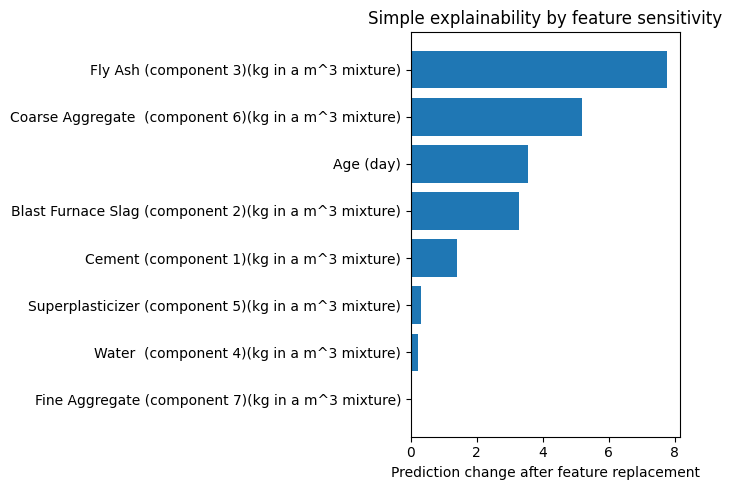

In [13]:
#@title Python Code - Model Explainability

# This example shows simple model explainability.
# We use concrete strength data.
# Small sensitivity checks reveal feature influence.

# Install lines are unnecessary here.

# Import quiet machine learning tools.
import os
import warnings

import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# Silence extra TensorFlow warnings.
warnings.filterwarnings("ignore")
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

tf.get_logger().setLevel("ERROR")

# Set deterministic random seeds.
np.random.seed(7)
random.seed(7)

tf.random.set_seed(7)

# Load a small civil dataset directly from the source.
data_url = (
    "https://raw.githubusercontent.com/mhrafiei/data/main/"

    "concrete_compressive_strength.csv")

df = pd.read_csv(data_url)

print("TensorFlow version:", tf.__version__)
print("Rows and columns:", df.shape)

# Separate inputs and target.
X = df.iloc[:, :-1].copy().astype("float32")
y = df.iloc[:, -1].copy().astype("float32")

feature_names = list(X.columns)

# Create train and test splits.
X_train, X_test, y_train, y_test = train_test_split(
    X,

    y,
    test_size=0.2,
    random_state=7,)

# Compute training statistics safely.
train_mean = X_train.mean().astype("float32")
train_std = X_train.std().replace(0, 1).astype("float32")

X_train_scaled = ((X_train - train_mean) / train_std).astype("float32")
X_test_scaled = ((X_test - train_mean) / train_std).astype("float32")

# Build a very small neural network.
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),

    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(1),])

# Compile the regression model.
model.compile(
    optimizer="adam",

    loss="mse",)

# Train quietly for a few epochs.
history = model.fit(
    X_train_scaled.values,

    y_train.values,
    epochs=40,
    batch_size=32,

    verbose=0,
    validation_split=0.1,)

# Evaluate simple prediction quality.
preds = model.predict(X_test_scaled.values, verbose=0).flatten()
mae = mean_absolute_error(y_test.values, preds)

print("Test MAE in MPa:", round(float(mae), 2))

# Pick one example for explanation.
example_index = 0
x_example = X_test.iloc[[example_index]].copy().astype("float32")

x_example_scaled = X_test_scaled.iloc[[example_index]].copy().astype("float32")

true_strength = float(y_test.iloc[example_index])
base_pred = float(model.predict(x_example_scaled.values, verbose=0)[0, 0])

# Print one prediction example.
print("True strength:", round(true_strength, 2), "MPa")
print("Predicted strength:", round(base_pred, 2), "MPa")

# Measure simple feature sensitivity.
importances = []

for name in feature_names:
    changed = x_example.copy()
    changed[name] = np.float32(train_mean[name])

    changed_scaled = ((changed - train_mean) / train_std).astype("float32")
    new_pred = float(model.predict(changed_scaled.values, verbose=0)[0, 0])

    impact = abs(base_pred - new_pred)
    importances.append(impact)

# Prepare sorted importance values.
importance_df = pd.DataFrame({
    "Feature": feature_names,

    "Importance": importances,})

importance_df = importance_df.sort_values("Importance", ascending=True)
most_important = importance_df.iloc[-1]

print("Largest influence:", most_important["Feature"])

# Draw a compact importance chart.
plt.figure(figsize=(7, 5))
plt.barh(

    importance_df["Feature"],
    importance_df["Importance"],)

plt.xlabel("Prediction change after feature replacement")
plt.title("Simple explainability by feature sensitivity")
plt.tight_layout()

plt.show()

## **2. Cohort Performance Analysis**

### **2.1. Defining CE Cohorts**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_13/Lecture_A/image_02_01.jpg?v=1777047301" width="250">



>* Cohorts group similar civil engineering cases.
>* They reveal hidden performance differences across conditions.

>* Choose cohorts with meaningful engineering rationale.
>* They reveal variation, imbalance, and unfairness.

>* Balance cohort size, specificity, and label quality.
>* Transparent cohorts reveal overlaps, risks, and mitigation needs.



Why cohorts matter: averages can hide weaker conditions.
Age median: 28.0 days.
Cement median: 272.9 kg/m^3.
                               count   mean  median    std
combined_cohort                                           
High curing age | High cement    350  49.16   46.68  14.71
High curing age | Low cement     356  33.87   33.36  11.80
Low curing age | High cement     165  29.70   27.92  12.56
Low curing age | Low cement      159  17.15   15.36   8.40


<Figure size 700x450 with 0 Axes>

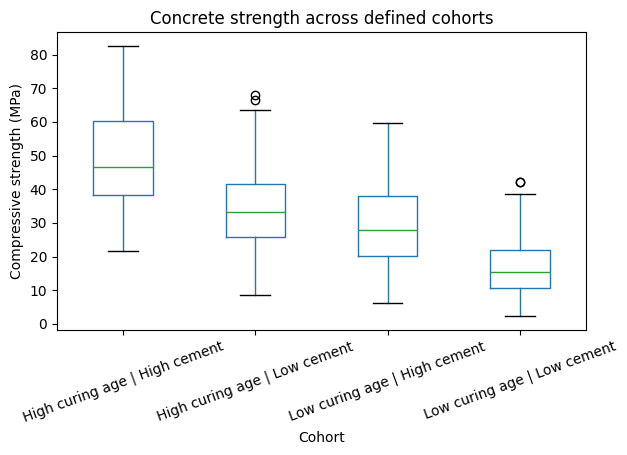

In [14]:
#@title Python Code - Defining CE Cohorts

# Cohorts compare meaningful engineering operating conditions.
# This example uses concrete strength data.
# Careful cohorts support trustworthy AI checks.

# Download a small civil dataset.
!wget -q -O concrete.csv "https://raw.githubusercontent.com/mhrafiei/data/main/concrete_compressive_strength.csv"

# Import beginner friendly libraries.
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

# Set a deterministic random seed.
np.random.seed(7)

# Load the downloaded dataset.
df = pd.read_csv("concrete.csv")

# Rename columns for easier teaching.
df.columns = [
    "cement", "slag", "fly_ash", "water",

    "superplasticizer", "coarse_agg", "fine_agg", "age",
    "strength"]

# Check the dataset size.
rows_ok = df.shape[0] > 100
cols_ok = df.shape[1] == 9

# Stop early if data looks wrong.
if not rows_ok or not cols_ok:
    raise ValueError("Dataset shape is unexpected.")

# Define meaningful engineering cohorts.
age_cut = df["age"].median()
cement_cut = df["cement"].median()

# Create low and high age groups.
df["age_cohort"] = "Low curing age"
df.loc[df["age"] >= age_cut, "age_cohort"] = "High curing age"

# Create low and high cement groups.
df["cement_cohort"] = "Low cement"
df.loc[df["cement"] >= cement_cut, "cement_cohort"] = "High cement"

# Build a combined cohort label.
df["combined_cohort"] = (
    df["age_cohort"] + " | " + df["cement_cohort"])

# Summarize each combined cohort.
summary = df.groupby("combined_cohort")["strength"].agg(
    ["count", "mean", "median", "std"]

).round(2)

# Print a short teaching message.
print("Why cohorts matter: averages can hide weaker conditions.")
print("Age median:", round(age_cut, 1), "days.")

print("Cement median:", round(cement_cut, 1), "kg/m^3.")
print(summary)

# Create one compact comparison figure.
plt.figure(figsize=(7, 4.5))

# Draw a simple boxplot.
df.boxplot(column="strength", by="combined_cohort", grid=False)

# Add clear labels for beginners.
plt.suptitle("")
plt.title("Concrete strength across defined cohorts")

plt.xlabel("Cohort")
plt.ylabel("Compressive strength (MPa)")
plt.xticks(rotation=20)

# Tight layout keeps labels readable.
plt.tight_layout()
plt.show()

### **2.2. Group Metric Comparison**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_13/Lecture_A/image_02_02.jpg?v=1777047337" width="250">



>* Compare performance across groups, not averages.
>* Uneven results can create unfair engineering risks.

>* Choose metrics that reflect real risks.
>* Compare groups for meaningful performance gaps.

>* Judge gaps by impact and sample size.
>* Persistent disparities can create unfair safety risks.



TensorFlow version: 2.21.0
Test samples: 258
Age median days: 28.0
Cement median kg/m^3: 272.9
          Cohort  Count   MAE  RMSE    R2
  Older concrete     75 11.14 14.15 -0.01
Younger concrete    183  8.03 10.24  0.51
   Higher cement    115  9.04 11.38  0.52
    Lower cement    143  8.85 11.62  0.21


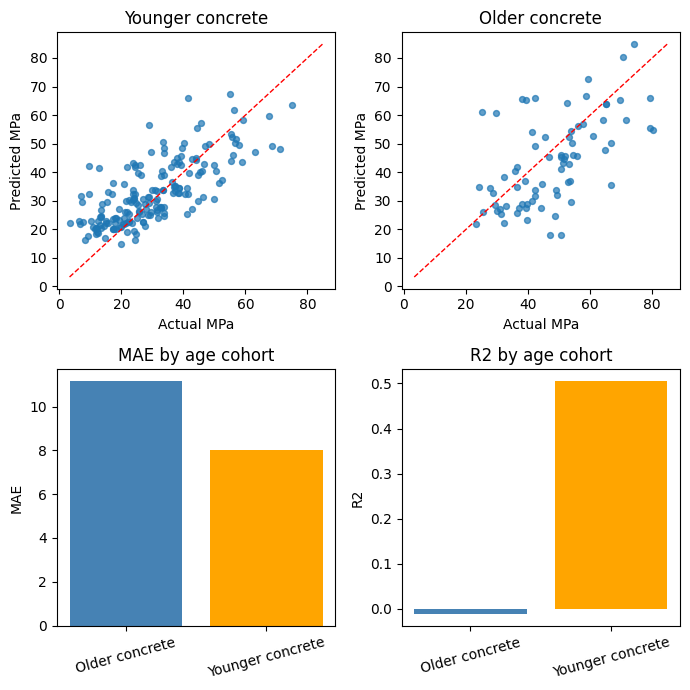

In [15]:
#@title Python Code - Group Metric Comparison

# Compare model metrics across concrete cohorts.
# This example uses a small TensorFlow regressor.
# Cohort analysis reveals hidden performance gaps.

# Import quiet libraries for clean output.
import os, warnings, random
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# Import TensorFlow and helper metrics.
import tensorflow as tf
from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

tf.get_logger().setLevel('ERROR')
random.seed(7)
np.random.seed(7)

tf.random.set_seed(7)

# Download the concrete dataset file.
!wget -q https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls

# Load the spreadsheet into pandas.
df = pd.read_excel('Concrete_Data.xls')
df.columns = ['cement', 'slag', 'fly_ash', 'water',

              'superplasticizer', 'coarse_agg', 'fine_agg',
              'age', 'strength']

# Check basic dataset size safely.
if len(df) < 100:
    raise ValueError('Dataset is unexpectedly small.')

# Split features and target values.
X = df.drop(columns=['strength']).copy()
y = df['strength'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=7)

# Standardize using training statistics only.
train_mean = X_train.mean()
train_std = X_train.std().replace(0, 1)

X_train_scaled = (X_train - train_mean) / train_std
X_test_scaled = (X_test - train_mean) / train_std

# Build a lightweight regression network.
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),

    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1)])

# Compile the model for regression.
model.compile(
    optimizer='adam',

    loss='mse',
    metrics=['mae'])

# Train quietly for a few epochs.
model.fit(
    X_train_scaled, y_train,

    validation_split=0.2,
    epochs=60, batch_size=32,
    verbose=0)

# Predict strengths on test data.
y_pred = model.predict(X_test_scaled, verbose=0).flatten()
results = X_test.copy()

results['actual'] = y_test.values
results['predicted'] = y_pred

# Create simple cohort labels.
age_cut = df['age'].median()
cement_cut = df['cement'].median()

results['age_group'] = np.where(results['age'] <= age_cut,
                                'Younger concrete',
                                'Older concrete')

results['cement_group'] = np.where(results['cement'] <= cement_cut,
                                   'Lower cement',
                                   'Higher cement')

# Define a beginner friendly metric function.
def cohort_metrics(frame, label_name):
    rows = []

    groups = frame[label_name].unique()

    for group in groups:
        part = frame[frame[label_name] == group]
        mae = mean_absolute_error(part['actual'], part['predicted'])

        rmse = np.sqrt(mean_squared_error(part['actual'], part['predicted']))
        r2 = r2_score(part['actual'], part['predicted'])
        rows.append([group, len(part), mae, rmse, r2])

    table = pd.DataFrame(
        rows,
        columns=['Cohort', 'Count', 'MAE', 'RMSE', 'R2'])

    return table.sort_values('Cohort').reset_index(drop=True)

# Compute metrics for two cohort definitions.
age_table = cohort_metrics(results, 'age_group')
cement_table = cohort_metrics(results, 'cement_group')

summary = pd.concat([age_table, cement_table], ignore_index=True)
summary[['MAE', 'RMSE', 'R2']] = summary[['MAE', 'RMSE', 'R2']].round(2)

# Print a compact teaching summary.
print('TensorFlow version:', tf.__version__)
print('Test samples:', len(results))

print('Age median days:', round(float(age_cut), 1))
print('Cement median kg/m^3:', round(float(cement_cut), 1))
print(summary.to_string(index=False))

# Prepare two age cohorts for plotting.
young = results[results['age_group'] == 'Younger concrete']
old = results[results['age_group'] == 'Older concrete']

plot_table = age_table.set_index('Cohort')

# Create compact plots for comparison.
fig, axes = plt.subplots(2, 2, figsize=(7, 7))
axes[0, 0].scatter(young['actual'], young['predicted'], s=18, alpha=0.7)

axes[0, 0].set_title('Younger concrete')
axes[0, 0].set_xlabel('Actual MPa')
axes[0, 0].set_ylabel('Predicted MPa')

# Plot the older cohort scatter.
axes[0, 1].scatter(old['actual'], old['predicted'], s=18, alpha=0.7)
axes[0, 1].set_title('Older concrete')

axes[0, 1].set_xlabel('Actual MPa')
axes[0, 1].set_ylabel('Predicted MPa')

# Add a reference diagonal line.
low_val = min(results['actual'].min(), results['predicted'].min())
high_val = max(results['actual'].max(), results['predicted'].max())

for ax in [axes[0, 0], axes[0, 1]]:
    ax.plot([low_val, high_val], [low_val, high_val], 'r--', linewidth=1)

# Draw compact MAE comparison bars.
axes[1, 0].bar(plot_table.index, plot_table['MAE'], color=['steelblue', 'orange'])
axes[1, 0].set_title('MAE by age cohort')

axes[1, 0].set_ylabel('MAE')
axes[1, 0].tick_params(axis='x', rotation=15)

# Draw compact R2 comparison bars.
axes[1, 1].bar(plot_table.index, plot_table['R2'], color=['steelblue', 'orange'])
axes[1, 1].set_title('R2 by age cohort')

axes[1, 1].set_ylabel('R2')
axes[1, 1].tick_params(axis='x', rotation=15)

# Finish the figure neatly.
plt.tight_layout()
plt.show()

### **2.3. Gap Visualization**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_13/Lecture_A/image_02_03.jpg?v=1777047381" width="250">



>* Visuals quickly reveal cohort performance differences.
>* They guide deployment decisions and further review.

>* Show gap size and practical importance.
>* Check sample size and consistency carefully.

>* Find causes behind cohort performance gaps.
>* Use gaps to guide fair mitigation.



TensorFlow version: 2.21.0
Largest MAE gap: 1.3 MPa
Best cohort: middle_age | Worst cohort: old
Counts: [52, 12, 142]


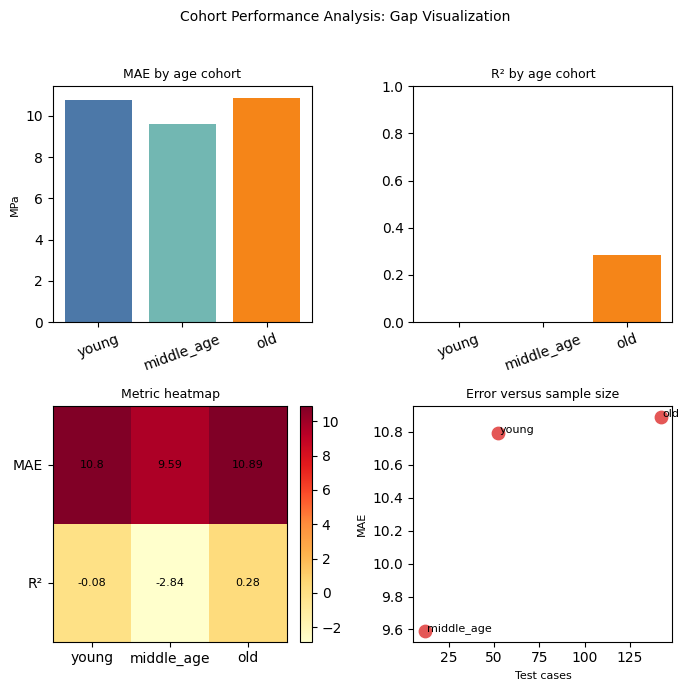

In [16]:
#@title Python Code - Gap Visualization

# This script shows cohort performance gaps.
# It uses concrete strength regression.
# One dashboard summarizes group differences.

# Import quiet libraries for Colab use.
import os, warnings, random
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# Import TensorFlow and helper metrics.
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, r2_score

tf.get_logger().setLevel('ERROR')

# Set seeds for repeatable results.
np.random.seed(7)
random.seed(7)

tf.random.set_seed(7)

# Print one short framework line.
print('TensorFlow version:', tf.__version__)

# Download the concrete dataset.
!wget -q -O concrete_compressive_strength.csv "https://raw.githubusercontent.com/mhrafiei/data/main/concrete_compressive_strength.csv"

# Load the dataset safely.
df = pd.read_csv('concrete_compressive_strength.csv')
df.columns = ['cement', 'slag', 'fly_ash', 'water'] + ['superplasticizer'] + ['coarse_agg', 'fine_agg', 'age', 'strength']

if df.shape[0] < 100:
    raise ValueError('Dataset is unexpectedly small.')

# Create simple age cohorts.
df['cohort'] = 'middle_age'
df.loc[df['age'] <= 7, 'cohort'] = 'young'

df.loc[df['age'] >= 28, 'cohort'] = 'old'

# Split data into train and test.
shuffled = df.sample(frac=1.0, random_state=7).reset_index(drop=True)
split_index = int(0.8 * len(shuffled))

train_df = shuffled.iloc[:split_index].copy()
test_df = shuffled.iloc[split_index:].copy()

# Prepare feature columns.
feature_names = ['cement', 'slag', 'fly_ash', 'water']
feature_names += ['superplasticizer', 'coarse_agg']

feature_names += ['fine_agg', 'age']
X_train = train_df[feature_names].to_numpy(dtype='float32')

# Prepare targets and test features.
y_train = train_df['strength'].to_numpy(dtype='float32')
X_test = test_df[feature_names].to_numpy(dtype='float32')

y_test = test_df['strength'].to_numpy(dtype='float32')

# Check shapes before training.
if X_train.shape[1] != 8:
    raise ValueError('Feature count should be eight.')

if len(X_test) != len(test_df):
    raise ValueError('Test sizes do not match.')

# Standardize using training statistics.
train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0) + 1e-6

X_train = (X_train - train_mean) / train_std
X_test = (X_test - train_mean) / train_std

# Build a small regression model.
model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=(8,)))

model.add(tf.keras.layers.Dense(16, activation='relu'))
model.add(tf.keras.layers.Dense(8, activation='relu'))
model.add(tf.keras.layers.Dense(1))

# Compile the model quietly.
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=35, verbose=0)

y_pred = model.predict(X_test, verbose=0).reshape(-1)

# Store predictions for analysis.
results = test_df[['age', 'strength', 'cohort']].copy()
results['prediction'] = y_pred

results['abs_error'] = np.abs(results['strength'] - results['prediction'])

# Compute cohort metrics simply.
cohorts = ['young', 'middle_age', 'old']
counts = []

maes = []
r2s = []
for name in cohorts:

    part = results[results['cohort'] == name]
    counts.append(len(part))
    maes.append(mean_absolute_error(part['strength'], part['prediction']))

    r2s.append(r2_score(part['strength'], part['prediction']))

# Print a short interpretation summary.
gap_value = max(maes) - min(maes)
worst_name = cohorts[int(np.argmax(maes))]

best_name = cohorts[int(np.argmin(maes))]
print('Largest MAE gap:', round(float(gap_value), 2), 'MPa')
print('Best cohort:', best_name, '| Worst cohort:', worst_name)

print('Counts:', counts)

# Build a compact dashboard figure.
fig, axes = plt.subplots(2, 2, figsize=(7, 7))
fig.suptitle('Cohort Performance Analysis: Gap Visualization', fontsize=10)

# Plot grouped cohort errors.
axes[0, 0].bar(cohorts, maes, color=['#4c78a8', '#72b7b2', '#f58518'])
axes[0, 0].set_title('MAE by age cohort', fontsize=9)

axes[0, 0].set_ylabel('MPa', fontsize=8)
axes[0, 0].tick_params(axis='x', labelrotation=20)

# Plot grouped cohort fit scores.
axes[0, 1].bar(cohorts, r2s, color=['#4c78a8', '#72b7b2', '#f58518'])
axes[0, 1].set_title('R² by age cohort', fontsize=9)

axes[0, 1].set_ylim(0, 1)
axes[0, 1].tick_params(axis='x', labelrotation=20)

# Plot a small heatmap of metrics.
heat = np.array([maes, r2s], dtype='float32')
image = axes[1, 0].imshow(heat, cmap='YlOrRd', aspect='auto')

axes[1, 0].set_title('Metric heatmap', fontsize=9)
axes[1, 0].set_xticks([0, 1, 2], cohorts)
axes[1, 0].set_yticks([0, 1], ['MAE', 'R²'])

# Add heatmap values clearly.
for row in range(2):
    for col in range(3):

        value = round(float(heat[row, col]), 2)
        axes[1, 0].text(col, row, value, ha='center', va='center', fontsize=8)
fig.colorbar(image, ax=axes[1, 0], fraction=0.046)

# Plot sample size beside errors.
axes[1, 1].scatter(counts, maes, s=80, color='#e45756')
for i in range(3):

    axes[1, 1].text(counts[i] + 1, maes[i], cohorts[i], fontsize=8)
axes[1, 1].set_title('Error versus sample size', fontsize=9)
axes[1, 1].set_xlabel('Test cases', fontsize=8)

axes[1, 1].set_ylabel('MAE', fontsize=8)

# Tighten layout for readability.
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## **3. Mitigation Strategies**

### **3.1. Balanced Data Collection**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_13/Lecture_A/image_03_01.jpg?v=1777047433" width="250">



>* Performance gaps often reflect unbalanced training data.
>* Expand data to cover diverse conditions.

>* Find missing or weak-performing cohorts.
>* Collect targeted, well-documented data for each.

>* Imbalanced data can create unfair, unsafe decisions.
>* Keep rechecking cohorts with broader real-world data.



TensorFlow version: 2.21.0
Training counts before: 9000 bright and 1500 dim
Training counts after: 9000 bright and 6000 dim
cohort  test_size  before_acc  after_acc
bright       3000       0.882      0.890
   dim       3000       0.873      0.886
Dim errors before and after: 380 342


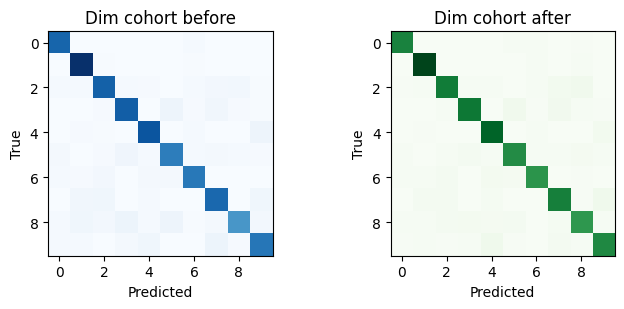

Balanced collection improved the weaker dim cohort.


In [17]:
#@title Python Code - Balanced Data Collection

# Balanced data can improve cohort reliability.
# This example uses MNIST as stand in.
# We compare dim and bright image cohorts.

# Import quiet libraries for Colab use.
import os, warnings, random
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# Import TensorFlow and helper metrics.
import tensorflow as tf
from sklearn.metrics import confusion_matrix

from sklearn.metrics import accuracy_score

# Silence TensorFlow warning messages.
tf.get_logger().setLevel('ERROR')
np.random.seed(7)

random.seed(7)
tf.random.set_seed(7)

# Show framework version briefly.
print('TensorFlow version:', tf.__version__)

# Load a small MNIST subset.
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train[:12000].astype('float32') / 255.0

x_test = x_test[:3000].astype('float32') / 255.0

# Keep labels aligned with subsets.
y_train = y_train[:12000]
y_test = y_test[:3000]

if x_train.shape[0] != y_train.shape[0]:
    raise ValueError('Training shapes do not match.')

# Create dim and bright cohorts.
train_dim = x_train * 0.35
test_dim = x_test * 0.35

train_bright = x_train.copy()
test_bright = x_test.copy()

# Build an imbalanced training set.
bright_count = 9000
dim_count = 1500

x_imbal = np.concatenate((
    train_bright[:bright_count],
    train_dim[:dim_count]

), axis=0)

y_imbal = np.concatenate((
    y_train[:bright_count],
    y_train[:dim_count]

), axis=0)

# Shuffle the imbalanced training set.
order1 = np.random.permutation(len(x_imbal))
x_imbal = x_imbal[order1]

y_imbal = y_imbal[order1]

# Build a more balanced training set.
rebalance_dim = 6000
x_bal = np.concatenate((

    train_bright[:bright_count],
    train_dim[:rebalance_dim]
), axis=0)

y_bal = np.concatenate((
    y_train[:bright_count],
    y_train[:rebalance_dim]

), axis=0)

# Shuffle the balanced training set.
order2 = np.random.permutation(len(x_bal))
x_bal = x_bal[order2]

y_bal = y_bal[order2]

# Prepare a shared test set.
x_test_all = np.concatenate((test_bright, test_dim), axis=0)
y_test_all = np.concatenate((y_test, y_test), axis=0)

cohort_test = np.array(['bright'] * len(y_test) + ['dim'] * len(y_test))

# Build a lightweight image model.
def make_model():
    model = tf.keras.Sequential([

        tf.keras.layers.Input(shape=(28, 28)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),

        tf.keras.layers.Dense(10, activation='softmax')])

    # Compile with simple settings.
    model.compile(
        optimizer='adam',

        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'])
    return model

# Train the first model silently.
model_before = make_model()
model_before.fit(

    x_imbal, y_imbal,
    epochs=3, batch_size=128,
    validation_split=0.1, verbose=0)

# Train the rebalanced model silently.
model_after = make_model()
model_after.fit(

    x_bal, y_bal,
    epochs=3, batch_size=128,
    validation_split=0.1, verbose=0)

# Predict labels for both models.
pred_before = model_before.predict(x_test_all, verbose=0).argmax(axis=1)
pred_after = model_after.predict(x_test_all, verbose=0).argmax(axis=1)

# Compute cohort accuracy values.
def cohort_accuracy(true_y, pred_y, cohort_names):
    rows = []

    for name in ['bright', 'dim']:
        mask = cohort_names == name
        acc = accuracy_score(true_y[mask], pred_y[mask])

        err = 1.0 - acc
        rows.append([name, round(acc, 3), round(err, 3), int(mask.sum())])

    # Return a small summary table.
    table = pd.DataFrame(
        rows,

        columns=['cohort', 'accuracy', 'error_rate', 'test_size'])
    return table

# Create before and after tables.
table_before = cohort_accuracy(y_test_all, pred_before, cohort_test)
table_after = cohort_accuracy(y_test_all, pred_after, cohort_test)

# Combine tables for compact printing.
summary = table_before.copy()
summary.columns = ['cohort', 'before_acc', 'before_err', 'test_size']

summary['after_acc'] = table_after['accuracy']
summary['after_err'] = table_after['error_rate']
summary = summary[['cohort', 'test_size', 'before_acc', 'after_acc']]

# Compute dim cohort confusion matrices.
dim_mask = cohort_test == 'dim'
cm_before = confusion_matrix(y_test_all[dim_mask], pred_before[dim_mask])

cm_after = confusion_matrix(y_test_all[dim_mask], pred_after[dim_mask])

# Summarize dim cohort mistakes.
dim_errors_before = int((pred_before[dim_mask] != y_test_all[dim_mask]).sum())
dim_errors_after = int((pred_after[dim_mask] != y_test_all[dim_mask]).sum())

# Print compact teaching results.
print('Training counts before:', bright_count, 'bright and', dim_count, 'dim')
print('Training counts after:', bright_count, 'bright and', rebalance_dim, 'dim')

print(summary.to_string(index=False))
print('Dim errors before and after:', dim_errors_before, dim_errors_after)

# Plot dim cohort confusion matrices.
fig, axes = plt.subplots(1, 2, figsize=(7, 3.2))
axes[0].imshow(cm_before, cmap='Blues')

axes[0].set_title('Dim cohort before')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Draw the second matrix.
axes[1].imshow(cm_after, cmap='Greens')
axes[1].set_title('Dim cohort after')

axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

# Finish the compact figure.
plt.tight_layout()
plt.show()

print('Balanced collection improved the weaker dim cohort.')

### **3.2. Targeted Model Retraining**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_13/Lecture_A/image_03_02.jpg?v=1777047474" width="250">



>* Retrain models for weak-performing cohorts.
>* Reduce risky gaps in critical conditions.

>* Diagnose causes before retraining weak cohorts.
>* Use quality data and reevaluate iteratively.

>* Retraining needs discipline to avoid new risks.
>* Document changes and keep monitoring all cohorts.



TensorFlow version: 2.21.0
Cohort table:
     Model Cohort  Count  Accuracy
  Baseline  clear   1052     0.951
  Baseline    dim    948     0.900
Reweighted  clear   1052     0.952
Reweighted    dim    948     0.893
Baseline gap: 0.051
Reweighted gap: 0.059


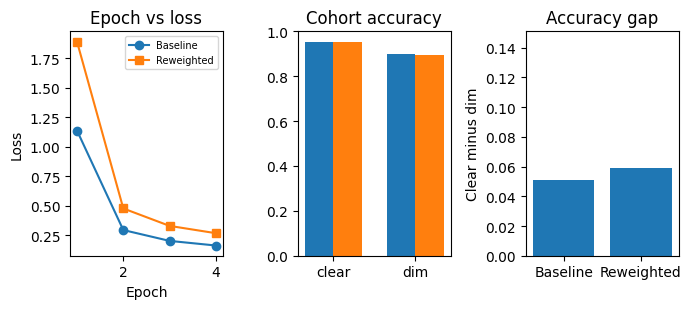

In [18]:
#@title Python Code - Targeted Model Retraining

# This example shows targeted retraining ideas.
# We compare baseline and reweighted training.
# Cohort gaps matter in engineering decisions.

import os, warnings, random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')
import tensorflow as tf

from sklearn.metrics import accuracy_score

tf.get_logger().setLevel('ERROR')
np.random.seed(7)
random.seed(7)

tf.random.set_seed(7)

# Show the framework version.
print('TensorFlow version:', tf.__version__)

# Load a small MNIST subset.
mnist = tf.keras.datasets.mnist
(train_x, train_y), (test_x, test_y) = mnist.load_data()

# Keep the dataset lightweight.
train_n = 8000
test_n = 2000

train_x = train_x[:train_n].astype('float32') / 255.0
train_y = train_y[:train_n]

test_x = test_x[:test_n].astype('float32') / 255.0
test_y = test_y[:test_n]

# Add the channel dimension.
train_x = np.expand_dims(train_x, -1)
test_x = np.expand_dims(test_x, -1)

# Build two simple cohorts.
train_cohort = np.where(train_y <= 4, 'clear', 'dim')
test_cohort = np.where(test_y <= 4, 'clear', 'dim')

# Make one cohort harder on purpose.
train_x_dim = train_x.copy()
test_x_dim = test_x.copy()

train_x_dim[train_cohort == 'dim'] *= 0.35
test_x_dim[test_cohort == 'dim'] *= 0.35
train_x = train_x_dim

test_x = test_x_dim

# Check basic shapes safely.
assert train_x.shape[0] == train_y.shape[0]
assert test_x.shape[0] == test_y.shape[0]

# Create a small beginner model.
def make_model():
    model = tf.keras.Sequential([

        tf.keras.layers.Input(shape=(28, 28, 1)),
        tf.keras.layers.Conv2D(8, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',

        metrics=['accuracy'])
    return model

# Train the baseline model.
baseline_model = make_model()
baseline_history = baseline_model.fit(

    train_x, train_y,
    epochs=4,
    batch_size=64,

    validation_split=0.1,
    verbose=0)

# Reweight the weaker cohort.
sample_weight = np.ones(train_y.shape[0], dtype='float32')
sample_weight[train_cohort == 'dim'] = 2.5

# Train the targeted retraining model.
reweighted_model = make_model()
reweighted_history = reweighted_model.fit(

    train_x, train_y,
    sample_weight=sample_weight,
    epochs=4,

    batch_size=64,
    validation_split=0.1,
    verbose=0)

# Evaluate one model by cohort.
def cohort_table(model, name):
    pred = model.predict(test_x, verbose=0)

    pred_y = np.argmax(pred, axis=1)
    rows = []
    for cohort_name in ['clear', 'dim']:

        mask = test_cohort == cohort_name
        acc = accuracy_score(test_y[mask], pred_y[mask])
        rows.append([name, cohort_name, int(mask.sum()), round(acc, 3)])

    return rows

# Build a compact results table.
rows = []
rows += cohort_table(baseline_model, 'Baseline')

rows += cohort_table(reweighted_model, 'Reweighted')
results = pd.DataFrame(rows, columns=['Model', 'Cohort', 'Count', 'Accuracy'])

# Compute the cohort gaps.
def gap_for(model_name):
    part = results[results['Model'] == model_name]

    clear_acc = float(part[part['Cohort'] == 'clear']['Accuracy'].iloc[0])
    dim_acc = float(part[part['Cohort'] == 'dim']['Accuracy'].iloc[0])
    return round(clear_acc - dim_acc, 3)

baseline_gap = gap_for('Baseline')
reweighted_gap = gap_for('Reweighted')

# Print a short interpretation.
print('Cohort table:')
print(results.to_string(index=False))

print('Baseline gap:', baseline_gap)
print('Reweighted gap:', reweighted_gap)

# Prepare values for one compact figure.
epochs = np.arange(1, 5)
base_loss = baseline_history.history['loss']

re_loss = reweighted_history.history['loss']

# Collect bar values safely.
clear_base = results.iloc[0]['Accuracy']
dim_base = results.iloc[1]['Accuracy']

clear_re = results.iloc[2]['Accuracy']
dim_re = results.iloc[3]['Accuracy']

# Draw one figure with three panels.
fig, axes = plt.subplots(1, 3, figsize=(7, 3.2))
axes[0].plot(epochs, base_loss, marker='o', label='Baseline')

axes[0].plot(epochs, re_loss, marker='s', label='Reweighted')
axes[0].set_title('Epoch vs loss')
axes[0].set_xlabel('Epoch')

axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=7)

# Plot cohort accuracies.
labels = ['clear', 'dim']
xpos = np.arange(2)

width = 0.35
axes[1].bar(xpos - width / 2, [clear_base, dim_base], width)
axes[1].bar(xpos + width / 2, [clear_re, dim_re], width)

axes[1].set_xticks(xpos)
axes[1].set_xticklabels(labels)
axes[1].set_ylim(0, 1)

axes[1].set_title('Cohort accuracy')

# Plot the gap comparison.
axes[2].bar(['Baseline', 'Reweighted'], [baseline_gap, reweighted_gap])
axes[2].set_ylim(0, max(0.01, baseline_gap + 0.1))

axes[2].set_title('Accuracy gap')
axes[2].set_ylabel('Clear minus dim')

# Finish the compact layout.
plt.tight_layout()
plt.show()

### **3.3. Deployment safeguards**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_13/Lecture_A/image_03_03.jpg?v=1777047515" width="250">



>* Safeguards limit AI use in weak contexts.
>* Require human review where errors matter.

>* Match oversight and thresholds to risk.
>* Redesign decisions to protect vulnerable cohorts.

>* Monitor cohorts continuously and intervene early.
>* Explain limits clearly and use safeguards.



TensorFlow version: 2.21.0
Chosen uncertainty threshold: 1.4
Automatic coverage percent: 100.0
Automatic mean absolute error: 10.09
Reviewed cases: 0
          cohort  mean_abs_error  review_rate_percent
younger_concrete           10.79                  0.0
  older_concrete            9.75                  0.0
Empty DataFrame
Columns: [cohort, actual_strength, predicted_strength, abs_error, uncertainty, decision]
Index: []


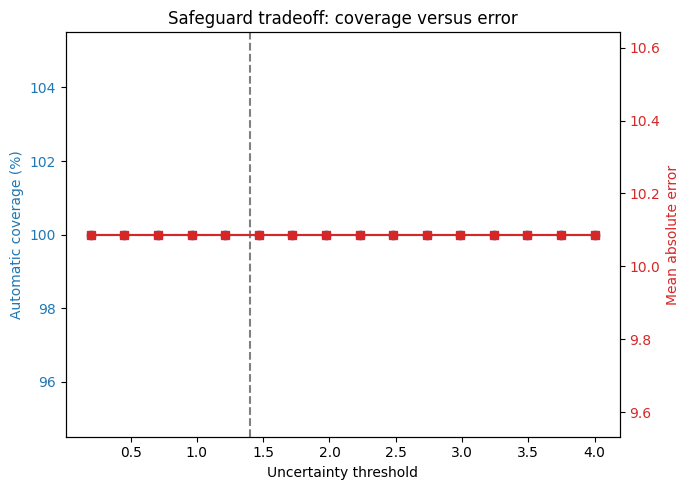

In [19]:
#@title Python Code - Deployment safeguards

# This example shows deployment safeguards.
# We use concrete strength predictions.
# Human review protects risky cases.

# Import quiet TensorFlow tools.
import os, warnings, random
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

warnings.filterwarnings('ignore')
import tensorflow as tf

tf.get_logger().setLevel('ERROR')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# Set deterministic random seeds.
np.random.seed(7)
random.seed(7)

tf.random.set_seed(7)
print('TensorFlow version:', tf.__version__)

# Download the small concrete dataset.
!wget -q -O concrete_compressive_strength.csv "https://raw.githubusercontent.com/mhrafiei/data/main/concrete_compressive_strength.csv"

# Load the civil engineering dataset.
df = pd.read_csv('concrete_compressive_strength.csv')
df.columns = [

    'cement', 'slag', 'flyash', 'water',
    'superplasticizer', 'coarse', 'fine', 'age', 'strength']

# Create a simple cohort label.
df['cohort'] = 'older_concrete'
df.loc[df['age'] < 28, 'cohort'] = 'younger_concrete'

features = df.drop(columns=['strength', 'cohort']).copy()
labels = df['strength'].astype('float32').copy()

# Split data for training and testing.
X_train, X_test, y_train, y_test, c_train, c_test = train_test_split(
    features, labels, df['cohort'], test_size=0.25, random_state=7)

# Standardize using training statistics.
train_mean = X_train.mean()
train_std = X_train.std().replace(0, 1)

X_train = (X_train - train_mean) / train_std
X_test = (X_test - train_mean) / train_std

# Convert tables into arrays.
X_train = X_train.to_numpy(dtype='float32')
X_test = X_test.to_numpy(dtype='float32')

y_train = y_train.to_numpy(dtype='float32')
y_test = y_test.to_numpy(dtype='float32')

# Check shapes before training.
assert X_train.shape[1] == 8
assert len(X_test) == len(y_test)

assert len(c_test) == len(y_test)

# Build a lightweight regression model.
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(8,)),

    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1)])

# Compile the model simply.
model.compile(
    optimizer='adam',

    loss='mse',
    metrics=['mae'])

# Train quietly for a few epochs.
model.fit(
    X_train, y_train,

    epochs=35,
    batch_size=32,
    validation_split=0.2,

    verbose=0)

# Predict concrete strength values.
preds = model.predict(X_test, verbose=0).reshape(-1)
abs_error = np.abs(preds - y_test)

# Estimate uncertainty with repeated predictions.
mc_preds = []
for i in range(20):

    sample_pred = model(X_test, training=True).numpy().reshape(-1)
    mc_preds.append(sample_pred)

mc_preds = np.array(mc_preds)
uncertainty = mc_preds.std(axis=0)

# Test several safeguard thresholds.
thresholds = np.linspace(0.2, 4.0, 16)
coverage_list = []

error_list = []
for threshold in thresholds:

    auto_mask = uncertainty <= threshold
    coverage = auto_mask.mean() * 100
    coverage_list.append(coverage)

    if auto_mask.sum() > 0:
        mean_error = abs_error[auto_mask].mean()
    else:

        mean_error = np.nan
    error_list.append(mean_error)

# Choose one practical safeguard threshold.
chosen_threshold = 1.4
auto_mask = uncertainty <= chosen_threshold

review_mask = uncertainty > chosen_threshold

# Build a compact results table.
results = pd.DataFrame({
    'cohort': c_test.to_numpy(),

    'actual_strength': np.round(y_test, 1),
    'predicted_strength': np.round(preds, 1),
    'abs_error': np.round(abs_error, 2),

    'uncertainty': np.round(uncertainty, 2),
    'decision': 'auto_use'})

# Flag uncertain cases for review.
results.loc[review_mask, 'decision'] = 'human_review'
flagged = results[results['decision'] == 'human_review'].copy()

flagged = flagged.sort_values('uncertainty', ascending=False)
flagged = flagged.head(6)

# Summarize performance by cohort.
summary_rows = []
for cohort_name in ['younger_concrete', 'older_concrete']:

    cohort_mask = results['cohort'] == cohort_name
    cohort_error = results.loc[cohort_mask, 'abs_error'].mean()
    cohort_review = (results.loc[cohort_mask, 'decision'] == 'human_review').mean()

    summary_rows.append([cohort_name, round(cohort_error, 2), round(100 * cohort_review, 1)])

summary = pd.DataFrame(
    summary_rows,
    columns=['cohort', 'mean_abs_error', 'review_rate_percent'])

# Print a short teaching summary.
print('Chosen uncertainty threshold:', chosen_threshold)
print('Automatic coverage percent:', round(100 * auto_mask.mean(), 1))

print('Automatic mean absolute error:', round(abs_error[auto_mask].mean(), 2))
print('Reviewed cases:', int(review_mask.sum()))
print(summary.to_string(index=False))

print(flagged.to_string(index=False))

# Create one compact safeguard plot.
fig, ax1 = plt.subplots(figsize=(7, 5))
ax1.plot(thresholds, coverage_list, marker='o', color='tab:blue')

ax1.set_xlabel('Uncertainty threshold')
ax1.set_ylabel('Automatic coverage (%)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Add error on a second axis.
ax2 = ax1.twinx()
ax2.plot(thresholds, error_list, marker='s', color='tab:red')

ax2.set_ylabel('Mean absolute error', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Mark the chosen safeguard threshold.
ax1.axvline(chosen_threshold, color='gray', linestyle='--')
plt.title('Safeguard tradeoff: coverage versus error')

plt.tight_layout()
plt.show()

# <font color="#418FDE" size="6.5" uppercase>**Risks and Fairness**</font>


In this lecture, you learned to:
- Identify safety, fairness, and transparency risks associated with AI models in civil engineering applications. 
- Conduct a simple cohort analysis to compare model performance across different groups or conditions. 
- Interpret cohort analysis results and propose mitigations for identified performance gaps. 

In the next Lecture (Lecture B), we will go over 'Model Cards and Governance'